In [4]:
# within versus across session decoding comparisons (of estimates: E)
#       corr. with shift in prior (risky/safe/); stress-level (auc)
# encoding model parameter comparison (ses1 vs. 2)

import pandas as pd
import os.path as op
import numpy as np
from os import listdir
#import pingouin
import matplotlib.pyplot as plt
import seaborn as sns


bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f[4:] for f in listdir(bids_folder) if f[0:3] == 'sub']

from stress_risk.utils.data import get_data
#df = get_data(bids_folder = bids_folder_behav)
#group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


In [29]:
# decoding: look only at session 2, compare within with across sessions E (numerosity estimate)

Es_within = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/within_ses_decodedE.csv')
Es_across = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/across_ses_decodedE.csv')

Es_within = Es_within.set_index(['subject', 'trial_nr', 'session']).rename(mapper={'E':'E_w', 'sd':'sd_w'}, axis=1).xs(2,0,'session')
Es_across = Es_across.set_index(['subject', 'trial_nr']).rename(mapper={'E':'E_a', 'sd':'sd_a'}, axis=1)


In [30]:
from stress_risk.utils.data import add_cond2df

Es = Es_within.join(Es_across).set_index('risky_first', append=True)
Es = add_cond2df(Es)

#len(Es.reset_index()['subject'].unique()) # sub-1 ses-2 missing! 
Es['E_dif'] = Es['E_a'] - Es['E_w']
Es

E_w      sd_w       E_a      sd_a    n1  \
subject trial_nr risky_first                                                 
2       1        False        3.630729  0.237235  3.227458  0.480335  10.0   
                 False        3.630729  0.237235  3.227458  0.480335  10.0   
        2        False        3.215811  0.250970  3.158594  0.693151  14.0   
                 False        3.215811  0.250970  3.158594  0.693151  14.0   
        3        False        3.268363  0.630426  3.231419  0.480769  14.0   
...                                ...       ...       ...       ...   ...   
61      118      True         3.930218  0.220174  2.644663  0.140344  34.0   
        119      True         1.928028  0.033986  2.436559  0.227761  34.0   
                 True         1.928028  0.033986  2.436559  0.227761  34.0   
        120      True         4.440225  0.185782  3.617215  0.254384  42.0   
                 True         4.440225  0.185782  3.617215  0.254384  42.0   

                              group    log_n1     E_dif  
subject trial_nr risky_first                             
2       1        False            0  2.302585 -0.403270  
                 False            0  2.302585 -0.403270  
        2        False            0  2.639057 -0.057217  
                 False            0  2.639057 -0.057217  
        3        False            0  2.639057 -0.036944  
...                             ...       ...       ...  
61      118      True             0  3.526361 -1.285555  
        119      True             0  3.526361  0.508531  
                 True             0  3.526361  0.508531  
        120      True             0  3.737670 -0.823009  
                 True             0  3.737670 -0.823009  

[11651 rows x 8 columns]

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-4.46365,91.797963,two-sided,0.000023,"[-0.19, -0.07]",0.905211,851.152,0.993328


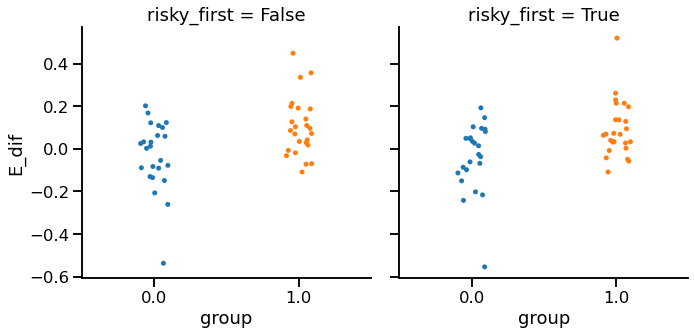

In [66]:
temp = Es.groupby(['subject', 'risky_first']).mean().set_index('group', append=True) # , 'risky_first'
sns.set_context('talk')
sns.catplot(data=temp.reset_index(), x='group', y='E_dif',  col='risky_first') #kind='bar',
pingouin.anova(data=temp.reset_index(), dv='E_dif', between='group')
pingouin.ttest(temp.xs(0,0,'group')['E_dif'], temp.xs(1,0,'group')['E_dif'])

# pingouin.corr(Es['E_w'], Es['E_a']) # do correlate with each other

In [5]:
# correlation with prior shift from NLC model

name_prior = 'risky_prior'
n_model = 1
df_prior_shift = pd.read_csv(f'/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_{name_prior}_model-{n_model}.csv')
df_prior_shift = df_prior_shift.set_index('subject')


In [6]:
from utils import get_stress_level
df_auc = get_stress_level()

df = get_data(bids_folder = bids_folder_behav)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)
df_prior_shift = df_prior_shift.join(group_mapping).join(df_auc)

In [10]:
# linear model, only works with behav_fit environment
import bambi

formulae = 'risky_prior_mu ~ 0 + AUC*group'
model = bambi.Model(formulae, data=df_prior_shift.dropna())
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [AUC, group, AUC:group, risky_prior_mu_sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.


/Users/mrenke/mambaforge/envs/behav_fit2/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


Text(0.5, 1.0, 'p(beta)>0 = 0.412')

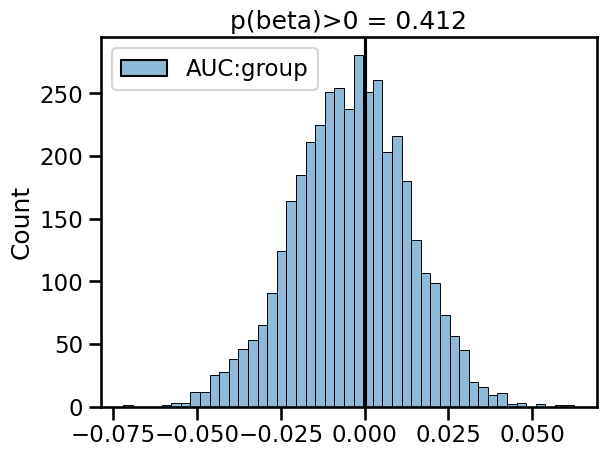

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

post = traces.posterior['AUC:group'].to_dataframe() # 'group', 'AUC:group', AUC
p = np.round(np.mean(post>0), 3)[0]
sns.set_context('talk')
sns.histplot(post)
plt.axvline(0, c='black')
plt.title(f'p(beta)>0 = {p}')

In [8]:
pingouin.mediation_analysis(df_prior_shift,x='group',m='AUC',y='risky_prior_mu')

,path,coef,se,pval,CI[2.5%],CI[97.5%],sig
0,AUC ~ X,4.795067,0.896360,2.557270e-06,2.991823,6.598310,Yes
1,Y ~ AUC,0.036976,0.008587,8.393367e-05,0.019700,0.054251,Yes
2,Total,0.476016,0.037770,1.106048e-16,0.400032,0.551999,Yes
3,Direct,0.480592,0.048413,5.137811e-13,0.383141,0.578043,Yes
4,Indirect,-0.004577,0.034644,9.560000e-01,-0.085419,0.052858,No


In [ ]:
df_Es = Es.groupby(['subject']).mean()
df_comb = df_prior_shift.join(df_Es[['E_dif', 'group']]).set_index('group', append=True)

Text(0.5, 1.0, 'group all \n r=0.25, p= 0.07908')

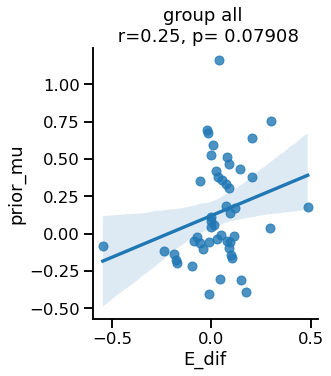

In [83]:
import matplotlib.pyplot as plt

gr = 'all'
t = df_comb#.xs(gr,0,'group')
sns.lmplot(data=t.reset_index() , x='E_dif', y = f'{name_prior}_mu') #, hue='group'
cor = pingouin.corr(t['E_dif'], t[f'{name_prior}_mu'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 5)
plt.title(f'group {gr} \n r={r_}, p= {p}')


In [5]:
from utils import get_stress_level
df_auc = get_stress_level()

df_comb = df_comb.join(df_auc)

NameError: name 'df_comb' is not defined

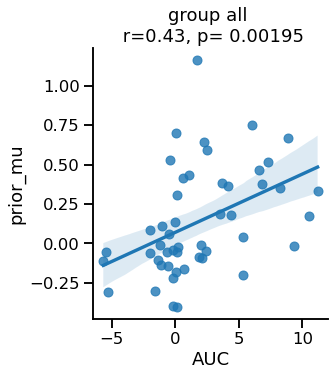

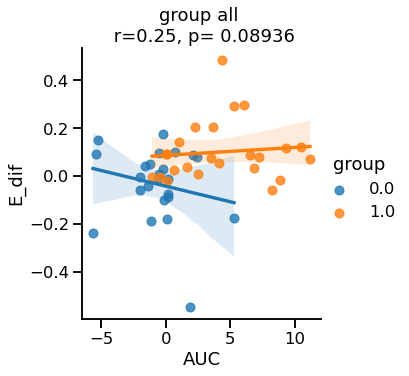

In [87]:
gr = 'all'
t = df_comb#.xs(gr,0,'group')

cor = pingouin.corr(t['AUC'], t[f'{name_prior}_mu'])
r_, p = np.round(cor['r'][0], 2), np.round(cor['p-val'][0], 5)
sns.lmplot(data=t.reset_index() , x='AUC', y = f'{name_prior}_mu').set(title=f'group {gr} \n r={r_}, p= {p}') #, hue='group'

cor = pingouin.corr(t['AUC'], t['E_dif'])
r_, p = np.round(cor['r'][0], 2), np.round(cor['p-val'][0], 5)
sns.lmplot(data=t.reset_index() , x='AUC', y = 'E_dif', hue='group').set(title=f'group {gr} \n r={r_}, p= {p}') #, hue='group'


In [36]:
# encoding: compare nPRF between sessions between groups

roi='NPC_R'
key = 'encoding_model.cv.denoise.retroicor'
session1 = 1

# prep. col names for df in next step
parameter_names = ['mu','sd','amplitude','baseline']
d1 = {}
for col_name in parameter_names:
    d1[col_name] = col_name  + f'_1'
d2 = {}
for col_name in parameter_names:
    d2[col_name] = col_name  + f'_2'


In [ ]:
from stress_risk.utils import Subject
from nilearn import image
from nilearn.maskers import NiftiMasker

pars_s = []
for subject in subFolders:
    sub = Subject(subject, bids_folder)

    # get average cv-r2 map from seesion 1 for voxel selection
    fn = op.join(bids_folder, 'derivatives', key, f'sub-{sub.subject}', f'ses-{session1}','func', f'sub-{sub.subject}_ses-{session1}_desc-cvr2.optim_space-T1w_pars.nii.gz')
    im_cvr2 = image.load_img(fn)

    mask = sub.get_volume_mask(roi=roi, session=1, epi_space=True) # anat from session1
    masker = NiftiMasker(mask_img=mask)

    cv_r2 = pd.DataFrame(masker.fit_transform(im_cvr2))
    r2_mask = cv_r2 > 0.0
    r2_mask = r2_mask.to_numpy().T
    n_voxels = r2_mask.sum()

    # get params
    pars1 = sub.get_prf_parameters_volume(session=1, cross_validated=False,denoise=True, retroicor=True,smoothed=False, pca_confounds=False,roi=roi)
    pars1 =pars1.rename(mapper=d1,axis=1)

    pars2 = sub.get_prf_parameters_volume(session=2, cross_validated=False,denoise=True, retroicor=True,smoothed=False, pca_confounds=False,roi=roi)
    pars2 = pars2.rename(mapper=d2,axis=1)

    pars = pd.concat([pars1,pars2],axis=1)
    pars = pars.reset_index().rename(mapper={'index':'voxel_n'},axis=1)
    pars['subject'] = int(sub.subject)

    pars = pars.set_index(['subject','voxel_n'])
    pars_s.append(pars)

pars_s = pd.concat(pars_s)  
pars_s = add_cond2df(pars_s)

            

In [89]:
from stress_risk.utils.data import add_cond2df

pars_s['mu_dif'] = pars_s['mu_2'] - pars_s['mu_1']
pars_s['sd_dif'] = pars_s['sd_2'] - pars_s['sd_1']
pars_s['amplitude_dif'] = pars_s['amplitude_2'] - pars_s['amplitude_1']
pars_s['baseline_dif'] = pars_s['baseline_2'] - pars_s['baseline_1']

pars_s = add_cond2df(pars_s)


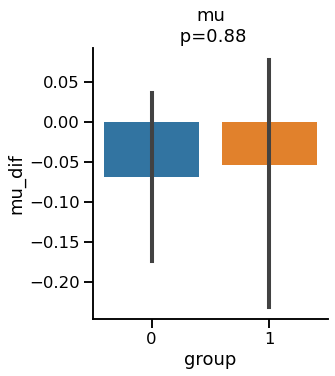

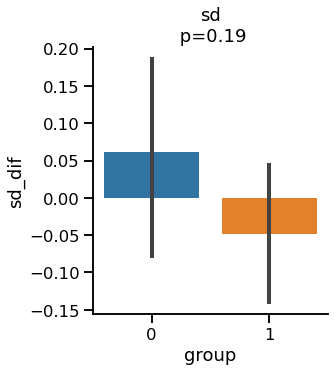

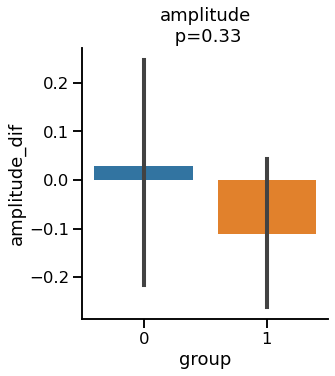

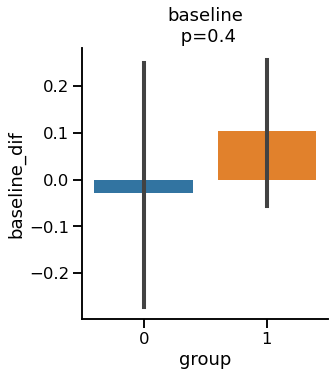

In [90]:
for param_name in parameter_names:
    temp = pars_s.groupby(['subject', 'group'])[[f'{param_name}_dif']].mean()
    ttest = pingouin.ttest(temp.xs(0,0,'group')[f'{param_name}_dif'], temp.xs(1,0,'group')[f'{param_name}_dif'])
    ttest_pval = np.round(ttest['p-val'][0],2)
    sns.catplot(data=temp.reset_index(), y = f'{param_name}_dif', x='group', kind='bar').set(title=f'{param_name}\n p={ttest_pval}')

In [ ]:

r_mus = pars_s.groupby(['subject', 'group']).apply(lambda d: pingouin.corr(d['mu_1'], d['mu_2']))

sns.lmplot(data=t,x='mu_1', y='mu_2')

,Source,ddof1,ddof2,F,p-unc,np2
0,group,1,48,0.683778,0.412381,0.014045


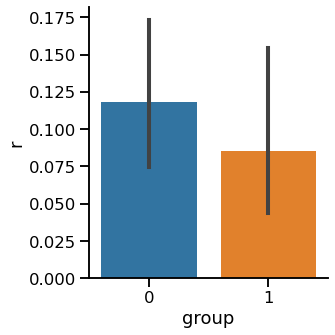

In [128]:
sns.catplot(data=r_mus.reset_index(),y='r',x='group', kind='bar')
pingouin.anova(data=r_mus.reset_index(),dv='r',between='group')

In [40]:
df_comb.set_index('subject')

,prior_mu,E_dif
subject,,
1,-0.009912,NaN
2,0.058431,NaN
5,-0.053908,0.010657
9,-0.301888,0.075062
10,-0.162133,0.143165
12,-0.085920,-0.012330
16,-0.114388,NaN
17,0.083260,NaN
19,-0.135085,NaN


In [46]:
len(Es.reset_index('subject')['subject'].unique())

49

In [47]:
Es.xs(16,0,'subject')

E_w      sd_w       E_a      sd_a    n1  group  \
trial_nr risky_first                                                        
1        False        2.468886  0.580402  2.243576  0.466998  14.0      0   
         False        2.468886  0.580402  2.243576  0.466998  14.0      0   
2        False        2.606770  0.100368  2.681145  0.724692  20.0      0   
         False        2.606770  0.100368  2.681145  0.724692  20.0      0   
3        False        3.309381  0.283019  3.472464  0.780659  14.0      0   
...                        ...       ...       ...       ...   ...    ...   
118      True         2.744190  0.265214  2.044873  0.339126  28.0      0   
119      True         3.677625  0.268451  3.371751  0.504592  60.0      0   
         True         3.677625  0.268451  3.371751  0.504592  60.0      0   
120      True         3.748278  0.336243  2.286982  0.476602  55.0      0   
         True         3.748278  0.336243  2.286982  0.476602  55.0      0   

                        log_n1     E_dif  
trial_nr risky_first                      
1        False        2.639057 -0.225310  
         False        2.639057 -0.225310  
2        False        2.995732  0.074375  
         False        2.995732  0.074375  
3        False        2.639057  0.163083  
...                        ...       ...  
118      True         3.332205 -0.699317  
119      True         4.094345 -0.305874  
         True         4.094345 -0.305874  
120      True         4.007333 -1.461296  
         True         4.007333 -1.461296  

[240 rows x 8 columns]

In [48]:
Es.groupby(['subject']).mean()

,E_w,sd_w,E_a,sd_a,n1,group,log_n1,E_dif
subject,,,,,,,,
2,3.149744,0.385497,3.160401,0.396349,25.630252,0.0,3.034178,0.010657
3,2.958690,0.363233,3.033752,0.285057,22.080169,1.0,2.907176,0.075062
4,3.119600,0.395564,3.262765,0.552751,28.216667,1.0,3.085291,0.143165
5,3.003591,0.267114,2.991261,0.319953,22.226891,0.0,2.932920,-0.012330
9,3.101369,0.345883,3.142496,0.458493,26.266667,0.0,3.017750,0.041127
10,2.945344,0.337047,3.047163,0.407219,23.550000,0.0,2.938489,0.101818
12,3.224730,0.337955,2.678193,0.485305,24.790698,0.0,3.002502,-0.546537
13,3.091855,0.466709,3.088027,0.408162,28.253165,1.0,3.092386,-0.003828
14,3.013764,0.441606,3.009943,0.452743,29.016667,1.0,3.109066,-0.003821
